# Data Preparation and Analysis 
## Remove interaction with PEA for JAIS paper (changed all analyses incl. CFA accordingly)

## A-priori Power Analysis

In [12]:
from statsmodels.stats.power import GofChisquarePower

power_analysis = GofChisquarePower()

sample_size = power_analysis.solve_power(
    effect_size=0.15, alpha=0.05, power=0.8, n_bins=2
)
print(f"Required sample size: {sample_size:.2f}")

Required sample size: 348.84


## Data Preparation

In [13]:
import pandas as pd
import json

raw_data = pd.read_csv("data/data_prolific.csv", sep=",")
raw_demographics = pd.read_csv("data/prolific_export_688a15651f7597f63277fb8d.csv", sep=",")

# Prepare the data
raw_data['result'] = raw_data['result'].apply(json.loads)
# Normalize the 'result' column into a new DataFrame
result_df = pd.json_normalize(raw_data['result'])

# Concatenate with the original DataFrame (excluding the old 'result' column if desired)
data_analysis = pd.concat([raw_data.drop(columns=['result']), result_df], axis=1)

# Rename columns: keep only the part after the last '.' if present
data_analysis.columns = [
    col.split('.')[-1] if '.' in col else col
    for col in data_analysis.columns
]

data_merged = data_analysis.merge(
    raw_demographics,
    left_on="PROLIFIC_PID",
    right_on="Participant id",
    how="left"
)

data_merged.shape

(367, 62)

## Drop observations

In [14]:
data_cleaned = data_merged.copy()

data_cleaned['HON1'] = data_cleaned['HON1'].astype(int)

print("Number of rows where HON != 5", (data_cleaned['HON1'] != 5).sum())
data_cleaned = data_cleaned[data_cleaned['HON1'] == 5]

data_cleaned.shape

Number of rows where HON != 5 2


(365, 62)

## Manipulation Check

In [15]:
import numpy as np
from scipy.stats import chi2_contingency

data_cleaned["ManipulationCheck_EE"] = data_cleaned["ManipulationCheck"].apply(
    lambda x: 1 if any("EnergyEfficiency" in str(item) for item in x) else 0
)
contingency_table = pd.crosstab(data_cleaned['group'], data_cleaned['ManipulationCheck_EE'])

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square: {chi2:.2f}, df: {dof}, p-value: {p_value:.3f}, Significant at α=0.05: {p_value < 0.05}")

Chi-square: 269.63, df: 1, p-value: 0.000, Significant at α=0.05: True


## Mean values for perceptional variables

In [16]:
# Numeric  colums
numeric_cols = [
    "userMessageCount", "total", "completion", "Age_x", "EXP1", "EXP2", "HON1",
    "QUAL1", "QUAL2", "QUAL3", "RES1", "RES3", "SAT1", "SAT2", "SAT3",
    "KNOWLEDGE", "PEA1", "PEA2", "PEA3", "PEB1", "PEB2", "PEB3", "PEB4"
]

data_cleaned[numeric_cols] = data_cleaned[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Mean Values
data_cleaned['QUAL_MEAN'] = data_cleaned[['QUAL1', 'QUAL2', 'QUAL3']].mean(axis=1)
data_cleaned['RES_MEAN'] = data_cleaned[['RES1', 'RES3']].mean(axis=1)
data_cleaned['SAT_MEAN'] = data_cleaned[['SAT1', 'SAT2', 'SAT3']].mean(axis=1)
data_cleaned['PEA_MEAN'] = data_cleaned[['PEA1', 'PEA2', 'PEA3']].mean(axis=1)
data_cleaned['PEB_MEAN'] = data_cleaned[['PEB1', 'PEB2', 'PEB3', 'PEB4']].mean(axis=1)

# Dictionary for recoding
recode_dict = {
    'pro': 'LLM',
    'mini': 'SLM'
}

# Option 1: Using .replace()
data_cleaned['choice'] = data_cleaned['choice'].replace(recode_dict)


# Add Average Token pro Prompt
data_cleaned['avg_tokens_per_prompt'] = data_cleaned['total'] / data_cleaned['userMessageCount']

## Sample Description

In [17]:
def create_descriptive_stats(data, column, category_name):
    """Create descriptive statistics for a given column with group distribution."""
    # Overall statistics
    overall_stats = (
        data.groupby(column, observed=True)
        .size()
        .reset_index(name="n")
        .assign(
            percentage=lambda x: (x["n"] / x["n"].sum() * 100).round(1),
            Category=category_name,
        )
    )

    # Group distribution statistics
    group_stats = (
        data.groupby([column, "group"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    # Calculate percentages for each group
    group_cols = [col for col in group_stats.columns if col != column]
    for col in group_cols:
        group_stats[f"{col}_pct"] = (
            group_stats[col] / group_stats[col].sum() * 100
        ).round(1)

    # Merge overall stats with group stats
    result = overall_stats.merge(group_stats, on=column, how="left")

    return result


# Create age groups
bins = [0, 18, 25, 35, 45, 55, 65, 75, np.inf]
labels = ["Under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65-74", "Over 75"]
data_cleaned["Age_group"] = pd.cut(
    data_cleaned["Age_x"], bins=bins, labels=labels, right=False
)

# Check for missing values in Age_group
if data_cleaned["Age_group"].isna().any():
    print("Missing values found in Age_group!")


# Define the custom order for gender
gender_order = ["Woman", "Man", "Genderqueer", "Nonbinary", "NA"]

# Convert Gender column to categorical with custom order
data_cleaned["Gender"] = pd.Categorical(
    data_cleaned["Gender"], categories=gender_order, ordered=True
)

education_order = [
    "HighSchool",
    "CollegeNoDegree",
    "AssociateDegree",
    "Bachelor",
    "Master",
    "Doctor",
    "NA",
]

# Convert the 'education' column to a categorical type with the defined order
data_cleaned["Education"] = pd.Categorical(
    data_cleaned["Education"], categories=education_order, ordered=True
)

# Now you can sort the DataFrame by 'education' in the correct order
data_cleaned = data_cleaned.sort_values("Education")

# Rename education values for better readability
education_rename_dict = {
    "HighSchool": "High school diploma or equivalent",
    "CollegeNoDegree": "Some college, no degree",
    "AssociateDegree": "Associate degree",
    "Bachelor": "Bachelor's degree",
    "Master": "Master’s degree",
    "Doctor": "Doctoral or professional degree",
    "NA": "Prefer not to say",
}

# Rename values using the dictionary with replace or map
data_cleaned["Education"] = data_cleaned["Education"].astype(str).replace(education_rename_dict)


# Generate descriptive statistics for all demographic variables
demographics_config = [
    ("group", "Group"),
    ("Gender", "Gender"),
    ("Age_group", "AgeGroup"),
    ("Education", "Education"),
]

demographic_dfs = [
    create_descriptive_stats(data_cleaned, column, category)
    for column, category in demographics_config
]


# Combine all demographic data
data_demographics = pd.concat(demographic_dfs, ignore_index=True)

# Create value column by extracting the non-null demographic value
demographic_columns = ["Gender", "Age_group", "Education"]
data_demographics["value"] = (
    data_demographics[demographic_columns].bfill(axis=1).iloc[:, 0]
)

# Get group names dynamically for column ordering
group_names = sorted(data_cleaned["group"].unique())
group_count_cols = group_names
group_pct_cols = [f"{name}_pct" for name in group_names]

# Reorder columns to include group distributions
column_order = (
    ["Category", "value", "n", "percentage"] + group_count_cols + group_pct_cols
)
data_demographics = data_demographics[column_order]


group_names = sorted(data_cleaned["group"].unique())
group1_name = group_names[0]  # First group
group2_name = group_names[1]  # Second group

column_order = [
    "Category",
    "value",
    "n",
    "percentage",
    group1_name,
    f"{group1_name}_pct",
    group2_name,
    f"{group2_name}_pct",
]


# Reorder columns
data_demographics = data_demographics[column_order]

# Rename columns for better display
data_demographics = data_demographics.rename(
    columns={
        "value": "Value",
        "n": "n",
        "percentage": "\\%",
        group1_name: "Control",
        f"{group1_name}_pct": "Control (\\%)",
        group2_name: "Treatment",
        f"{group2_name}_pct": "Treatment (\\%)",
    }
)

data_demographics

,Category,Value,n,\%,Control,Control (\%),Treatment,Treatment (\%)
0,Group,NaN,192,52.6,192,100.0,0,0.0
1,Group,NaN,173,47.4,0,0.0,173,100.0
2,Gender,Woman,166,45.6,85,44.5,81,46.8
3,Gender,Man,194,53.3,104,54.5,90,52.0
4,Gender,Genderqueer,1,0.3,1,0.5,0,0.0
5,Gender,Nonbinary,1,0.3,0,0.0,1,0.6
6,Gender,NA,2,0.5,1,0.5,1,0.6
7,AgeGroup,18-24,22,6.0,7,3.6,15,8.7
8,AgeGroup,25-34,96,26.3,51,26.6,45,26.0
9,AgeGroup,35-44,94,25.8,50,26.0,44,25.4


## Randomization Test

In [18]:
# Check if conditions differ in terms of age, gender, and education
from scipy import stats
from scipy.stats import chi2_contingency

# Gender
contingency_table = pd.crosstab(data_cleaned["group"], data_cleaned["Gender"])

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(
    f"Gender: Chi-square: {chi2:.4f}, df: {dof}, p-value: {p_value:.4f}, Significant at α=0.05: {p_value < 0.05}"
)


variables_to_test = {
    "Age": "Age_x",
    "Experience_1": "EXP1",
    "Experience_2": "EXP2",
    "Knowledge": "KNOWLEDGE",
    "Completion_time": "Time taken",
    "PEA_MEAN": "PEA_MEAN",
}

results = []
group_names = data_cleaned["group"].unique()

for var_name, col_name in variables_to_test.items():
    group1_data = data_cleaned[data_cleaned["group"] == group_names[0]][col_name]
    group2_data = data_cleaned[data_cleaned["group"] == group_names[1]][col_name]

    # Remove any NaN values for accurate sample size calculation
    group1_clean = group1_data.dropna()
    group2_clean = group2_data.dropna()

    t_stat, p_value = stats.ttest_ind(group1_clean, group2_clean)

    # Calculate degrees of freedom for independent t-test
    df = len(group1_clean) + len(group2_clean) - 2

    results.append(
        {
            "variable": var_name,
            "t_stat": round(t_stat, 2),
            "p_value": round(p_value, 3),
            "df": df,
            "significant": p_value < 0.05,
        }
    )

results_df = pd.DataFrame(results)
print(results_df)

Gender: Chi-square: 2.2220, df: 4, p-value: 0.6950, Significant at α=0.05: False
          variable  t_stat  p_value   df  significant
0              Age    1.35    0.179  363        False
1     Experience_1   -1.86    0.063  363        False
2     Experience_2    0.21    0.838  363        False
3        Knowledge    0.08    0.940  363        False
4  Completion_time    0.32    0.747  363        False
5         PEA_MEAN    1.31    0.191  363        False


## Confirmatory Factor Analysis

In [19]:
from semopy import Model
from semopy.stats import calc_stats

cfa_model = """
QUALITY =~ QUAL1 + QUAL2 + QUAL3
SATISFACTION =~ SAT1 + SAT2 + SAT3
"""

# Create and fit the model
model = Model(cfa_model)
results = model.fit(data_cleaned)
# Calculate and display fit statistics
stats = calc_stats(model)

print("=== MODEL FIT RESULTS ===")
print(f"Optimization successful: {results.success}")

print("\n=== FIT STATISTICS ===")
print(f"Chi-square: {stats['chi2'].item():.4f}")
print(f"Degrees of freedom: {stats['DoF'].item():.0f}")
print(f"P-value: {stats['chi2 p-value'].item():.4f}")
print(f"CFI: {stats['CFI'].item():.4f}")
print(f"TLI: {stats['TLI'].item():.4f}")
print(f"RMSEA: {stats['RMSEA'].item():.4f}")
print(f"AIC: {stats['AIC'].item():.4f}")
print(f"BIC: {stats['BIC'].item():.4f}")

# Get unstandardized estimates first
estimates = model.inspect()
standardized = model.inspect(what="std")

pd.set_option("display.float_format", "{:.3f}".format)
print(standardized[standardized["op"] == "~"])
pd.reset_option("display.float_format")

=== MODEL FIT RESULTS ===
Optimization successful: True

=== FIT STATISTICS ===
Chi-square: 23.8579
Degrees of freedom: 8
P-value: 0.0024
CFI: 0.9923
TLI: 0.9855
RMSEA: 0.0738
AIC: 25.8693
BIC: 76.5679
    lval op          rval  Estimate Std. Err z-value p-value
0  QUAL1  ~       QUALITY     1.000        -       -       -
1  QUAL2  ~       QUALITY     1.007    0.031  32.141   0.000
2  QUAL3  ~       QUALITY     1.011    0.033  30.376   0.000
3   SAT1  ~  SATISFACTION     1.000        -       -       -
4   SAT2  ~  SATISFACTION     1.188    0.055  21.714   0.000
5   SAT3  ~  SATISFACTION     1.192    0.056  21.443   0.000


In [20]:
all_params = model.inspect()
loadings_raw = all_params[all_params["op"] == "~"].copy()
variances = all_params[
    (all_params["op"] == "~~") & (all_params["lval"] == all_params["rval"])
].copy()

std_results = []
for _, loading_row in loadings_raw.iterrows():
    var = loading_row["lval"]
    factor = loading_row["rval"]
    loading_val = loading_row["Estimate"]
    factor_var_row = variances[variances["lval"] == factor]
    error_var_row = variances[variances["lval"] == var]
    if len(factor_var_row) > 0 and len(error_var_row) > 0:
        factor_var = factor_var_row["Estimate"].iloc[0]
        error_var = error_var_row["Estimate"].iloc[0]
        total_var = (loading_val ** 2) * factor_var + error_var
        std_loading = loading_val * np.sqrt(factor_var) / np.sqrt(total_var)
        std_results.append({"Factor": factor, "Indicator": var, "std_loading": std_loading})

std_df = pd.DataFrame(std_results)

# AVE und CR
ave_cr = std_df.groupby("Factor").apply(
    lambda g: pd.Series({
        "AVE": round((g["std_loading"] ** 2).mean(), 3),
        "CR": round(
            g["std_loading"].sum() ** 2 /
            (g["std_loading"].sum() ** 2 + (1 - g["std_loading"] ** 2).sum()),
            3
        )
    })
).reset_index()

print(std_df.to_string(index=False))
print("\n=== AVE & CR ===")
print(ave_cr.to_string(index=False))

      Factor Indicator  std_loading
     QUALITY     QUAL1     0.922330
     QUALITY     QUAL2     0.941038
     QUALITY     QUAL3     0.921412
SATISFACTION      SAT1     0.819464
SATISFACTION      SAT2     0.923507
SATISFACTION      SAT3     0.912491

=== AVE & CR ===
      Factor   AVE    CR
     QUALITY 0.862 0.949
SATISFACTION 0.786 0.916


## Group-wise decision

In [21]:
group_choice_count = (
    data_cleaned.groupby(["group", "choice"]).size().reset_index(name="count")
)
group_totals = group_choice_count.groupby("group")["count"].transform("sum")
group_choice_count["percentage"] = (
    group_choice_count["count"] / group_totals * 100
).round(1)

print(group_choice_count)

       group choice  count  percentage
0    Control    LLM    183        95.3
1    Control    SLM      9         4.7
2  Treatment    LLM    105        60.7
3  Treatment    SLM     68        39.3


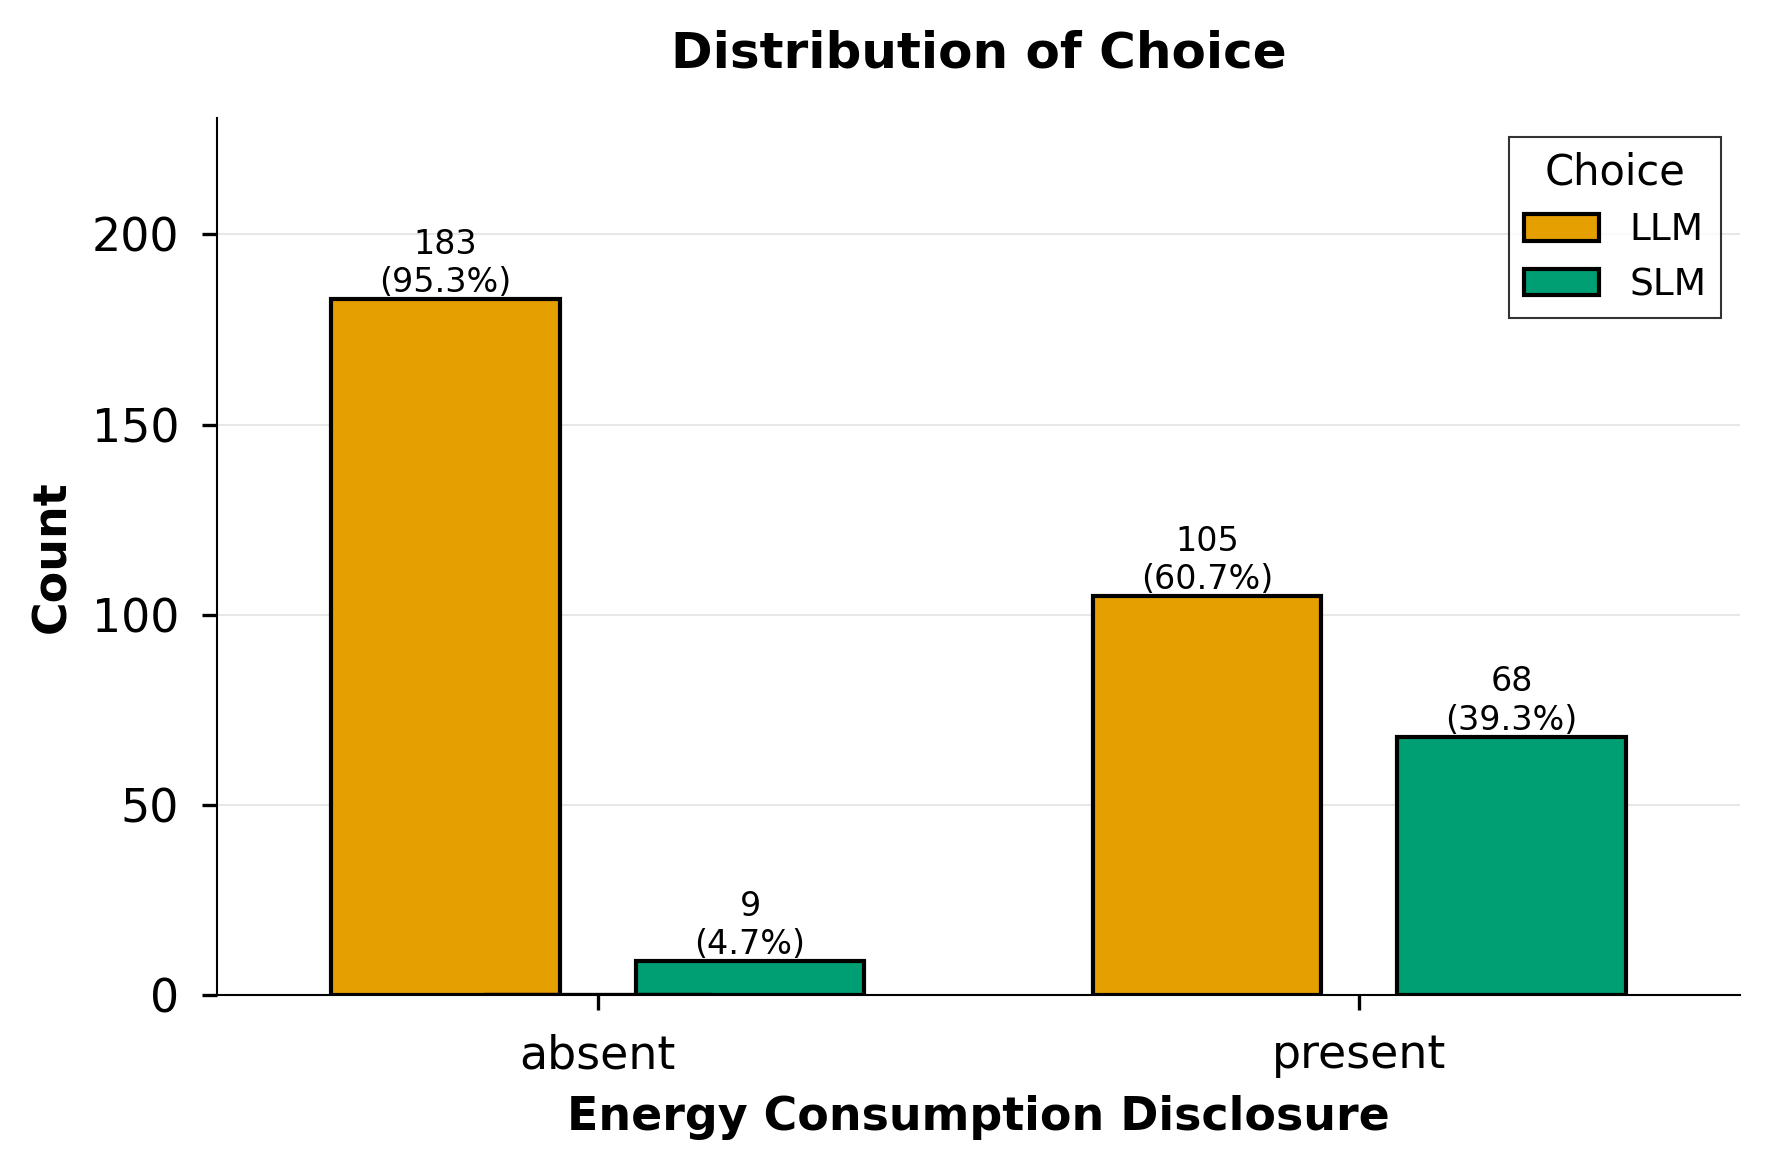

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use("seaborn-v0_8-paper")
sns.set_palette("colorblind")
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
plot_palette = {"LLM": "#E69F00", "SLM": "#009E73"}

# Plot-Kopie mit umbenannten Werten
label_map = {"Control": "absent", "Treatment": "present"}
data_plot = data_cleaned.copy()
data_plot["group"] = data_plot["group"].replace(label_map)
group_choice_count_plot = group_choice_count.copy()
group_choice_count_plot["group"] = group_choice_count_plot["group"].map(label_map)
plot = sns.countplot(
    data=data_plot,                  
    x="group",
    hue="choice",
    order=["absent", "present"],           
    ax=ax,
    palette=plot_palette,
    saturation=1,
    edgecolor="#000000",
    linewidth=1,
)
bar_width = 0.3  
for patch in ax.patches:
    current_x = patch.get_x()
    current_width = patch.get_width()
    center = current_x + current_width / 2
    patch.set_x(center - bar_width / 2)
    patch.set_width(bar_width)
ax.set_title("Distribution of Choice", fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("Count", fontsize=11, fontweight="bold")
ax.set_xlabel("Energy Consumption Disclosure", fontsize=11, fontweight="bold") 
ax.tick_params(axis="both", which="major", labelsize=11)
ax.tick_params(axis="x", rotation=0)
legend = ax.legend(
    title="Choice",
    title_fontsize=10,
    fontsize=9,
    frameon=True,
    fancybox=False,
    shadow=False,
    loc="upper right",
)
legend.get_frame().set_linewidth(0.5)
legend.get_frame().set_edgecolor("black")
for i, container in enumerate(ax.containers):
    labels = []
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            group_name = ["absent", "present"][j]                      
            choice_name = data_plot["choice"].unique()[i]
            mask = (group_choice_count_plot["group"] == group_name) & (   
                group_choice_count_plot["choice"] == choice_name
            )
            percentage = group_choice_count_plot[mask]["percentage"].iloc[0]
            labels.append(f"{int(height)}\n({percentage}%)")
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("img/img_JAIS/choice_distribution.pdf", bbox_inches="tight")
plt.savefig("img/img_JAIS/choice_distribution.svg", bbox_inches="tight")
plt.savefig("img/img_JAIS/choice_distribution.png", bbox_inches="tight", dpi=600)
plt.show()

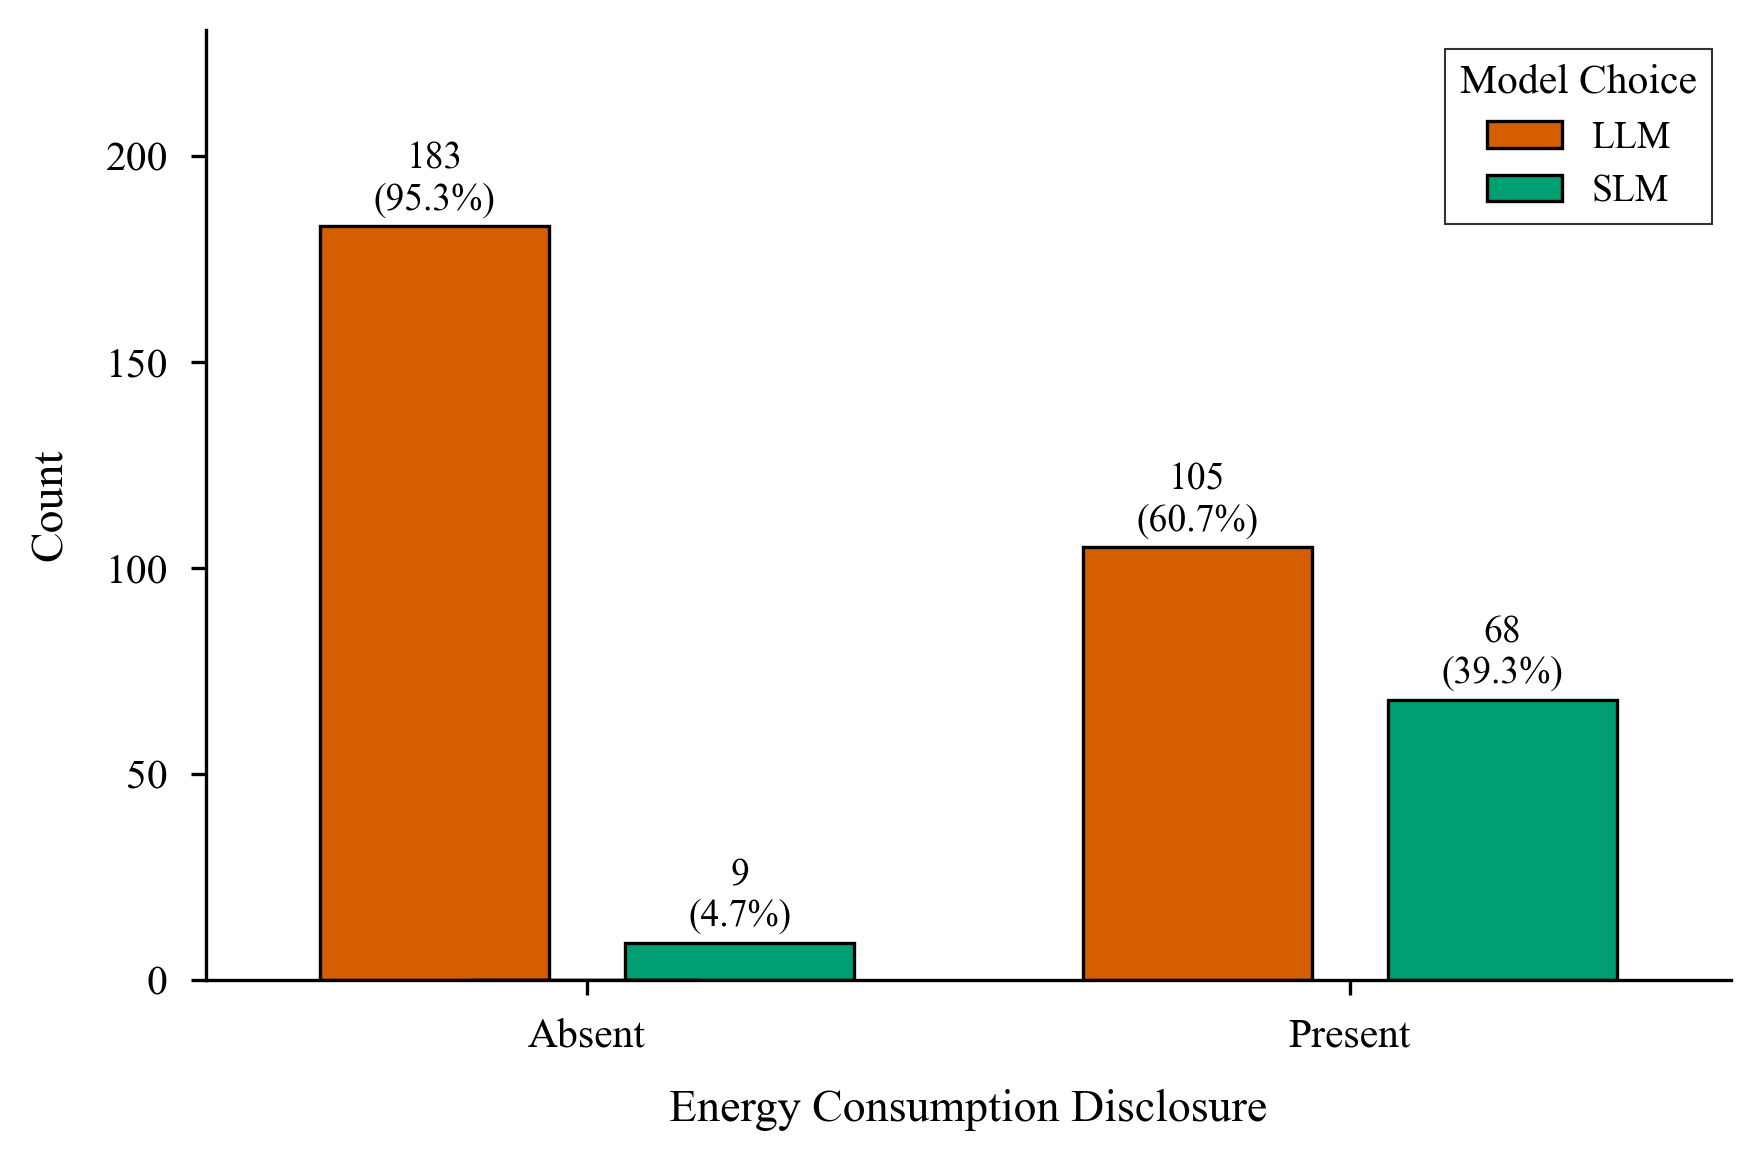

In [41]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "figure.dpi": 300,
})

fig, ax = plt.subplots(figsize=(6, 4))

plot_palette = {"LLM": "#D55E00", "SLM": "#009E73"}  

label_map = {"Control": "Absent", "Treatment": "Present"}
data_plot = data_cleaned.copy()
data_plot["group"] = data_plot["group"].replace(label_map)
group_choice_count_plot = group_choice_count.copy()
group_choice_count_plot["group"] = group_choice_count_plot["group"].map(label_map)

sns.countplot(
    data=data_plot,
    x="group",
    hue="choice",
    order=["Absent", "Present"],
    ax=ax,
    palette=plot_palette,
    saturation=1,
    edgecolor="black",
    linewidth=0.8,
)

bar_width = 0.3
for patch in ax.patches:
    center = patch.get_x() + patch.get_width() / 2
    patch.set_x(center - bar_width / 2)
    patch.set_width(bar_width)

# Achsen
ax.set_xlabel("Energy Consumption Disclosure", labelpad=8)
ax.set_ylabel("Count", labelpad=8)
ax.set_title("")  # Kein Titel — APA-Beschriftung erfolgt als Figure Caption im Text
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

# Balkenbeschriftung
for i, container in enumerate(ax.containers):
    labels = []
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            group_name = ["Absent", "Present"][j]
            choice_name = data_plot["choice"].unique()[i]
            mask = (
                (group_choice_count_plot["group"] == group_name) &
                (group_choice_count_plot["choice"] == choice_name)
            )
            pct = group_choice_count_plot[mask]["percentage"].iloc[0]
            labels.append(f"{int(height)}\n({pct}%)")
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, fontsize=9, padding=2)

# Legende
legend = ax.legend(
    title="Model Choice",
    title_fontsize=10,
    fontsize=9,
    frameon=True,
    fancybox=False,
    shadow=False,
    loc="upper right",
    edgecolor="black",
)
legend.get_frame().set_linewidth(0.5)

plt.tight_layout()
plt.savefig("img/img_JAIS/choice_distribution.pdf", bbox_inches="tight")
plt.savefig("img/img_JAIS/choice_distribution.svg", bbox_inches="tight")
plt.savefig("img/img_JAIS/choice_distribution.png", bbox_inches="tight", dpi=600)
plt.show()

## Odds Ratios

In [50]:
# Counts aus group_choice_count
slm_control   = group_choice_count.loc[(group_choice_count["group"] == "Control")   & (group_choice_count["choice"] == "SLM"), "count"].values[0]
llm_control   = group_choice_count.loc[(group_choice_count["group"] == "Control")   & (group_choice_count["choice"] == "LLM"), "count"].values[0]
slm_treatment = group_choice_count.loc[(group_choice_count["group"] == "Treatment") & (group_choice_count["choice"] == "SLM"), "count"].values[0]
llm_treatment = group_choice_count.loc[(group_choice_count["group"] == "Treatment") & (group_choice_count["choice"] == "LLM"), "count"].values[0]

OR = (slm_treatment / llm_treatment) / (slm_control / llm_control)
OR

np.float64(13.16825396825397)

## Logistic Regression

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

data_logit = data_cleaned.copy()

# Create TREAT and MINI columns
data_logit["TREAT"] = np.where(data_logit["group"] == "Control", 0, 1)  # 1 = Treatment
data_logit["MINI"] = np.where(data_logit["choice"] == "LLM", 0, 1)  # 1 = MINI (SLM)

# Create the mean and z-scored PEA variables
data_logit["PEA_MEAN_Z"] = (
    data_logit["PEA_MEAN"] - data_logit["PEA_MEAN"].mean()
) / data_logit["PEA_MEAN"].std()


step1 = smf.logit("MINI ~ TREAT", data=data_logit).fit()
# print(step1.summary())

step2 = smf.logit("MINI ~ TREAT + PEA_MEAN_Z", data=data_logit).fit()
# print(step2.summary())

step3 = smf.logit("MINI ~ TREAT * PEA_MEAN_Z", data=data_logit).fit()
print(step3.summary())

Optimization terminated successfully.
         Current function value: 0.417138
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.399546
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.392928
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   MINI   No. Observations:                  365
Model:                          Logit   Df Residuals:                      361
Method:                           MLE   Df Model:                            3
Date:                Thu, 22 Jan 2026   Pseudo R-squ.:                  0.2374
Time:                        11:38:01   Log-Likelihood:                -143.42
converged:                       True   LL-Null:                       -188.06
Covariance Type:            nonrobust   LLR p-value:                 3.133e-19
                       coef    std err          z      P>|z|  

In [ ]:
summary = pd.DataFrame(
    {
        "Coefficient": step3.params,
        "Std. Error": step3.bse,
        "z-value": step3.tvalues,
        "p-value": step3.pvalues,
        "2.5% CI": step3.conf_int()[0],
        "97.5% CI": step3.conf_int()[1],
        "Odds Ratio": np.exp(step3.params),
        "Odds Ratio 2.5% CI": np.exp(step3.conf_int()[0]),
        "Odds Ratio 97.5% CI": np.exp(step3.conf_int()[1]),
    }
)
summary.round(2)

,Coefficient,Std. Error,z-value,p-value,2.5% CI,97.5% CI,Odds Ratio,Odds Ratio 2.5% CI,Odds Ratio 97.5% CI
Intercept,-3.01,0.34,-8.79,0.00,-3.68,-2.34,0.05,0.03,0.10
TREAT,2.56,0.38,6.72,0.00,1.81,3.30,12.89,6.11,27.17
PEA_MEAN_Z,-0.16,0.32,-0.48,0.63,-0.79,0.48,0.86,0.45,1.62
TREAT:PEA_MEAN_Z,0.90,0.38,2.36,0.02,0.15,1.65,2.46,1.17,5.20


In [ ]:
print(
    f"$\\Chi^2$ ({step3.df_model}, {data_cleaned.shape[1]})={step3.llr:.2f}, p-value: {step3.llr_pvalue:.3f}"
)
print(f"Pseudo $R^2$: {step3.prsquared:.3f}")

$\Chi^2$ (3.0, 70)=89.28, p-value: 0.000
Pseudo $R^2$: 0.237


## DVs: t-test with correction for multiple comparison

In [ ]:
import pingouin as pg
from statsmodels.stats.multitest import multipletests

data_treatment = data_cleaned[data_cleaned["group"] == "Treatment"]

print(data_treatment.groupby("choice").size())

print(data_treatment.shape)

variables = ["avg_tokens_per_prompt", "userMessageCount", "SAT_MEAN", "QUAL_MEAN"]

results = []
p_values = []

for var in variables:
    groups = data_treatment["choice"].dropna().unique()
    group1, group2 = groups[:2]
    vals1 = data_treatment[data_treatment["choice"] == group1][var].dropna()
    vals2 = data_treatment[data_treatment["choice"] == group2][var].dropna()
    n1 = len(vals1)
    n2 = len(vals2)
    result = pg.mwu(x=vals1, y=vals2)
    u = result["U-val"].iloc[0]
    p = result["p-val"].iloc[0]
    r = result["RBC"].iloc[0] if "RBC" in result.columns else result["effsize"].iloc[0]
    med1 = vals1.median()
    med2 = vals2.median()
    results.append(
        {
            "variable": var,
            "U": u,

            "p": p,
            "r": r,
            "n1": n1,
            "n2": n2,
            "median1": med1,
            "median2": med2,
        }
    )
    p_values.append(p)

print(p_values)
_, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method="bonferroni")


for i, p_corr in enumerate(pvals_corrected):
    results[i]["p_bonf"] = p_corr

print(pvals_corrected)

choice
LLM    105
SLM     68
dtype: int64
(173, 70)
[np.float64(0.501036280649695), np.float64(0.9549946963929428), np.float64(0.004153127883343215), np.float64(0.002895472536665634)]
[1.         1.         0.01661251 0.01158189]


## Post-Hoc Power Analysis

In [ ]:
from statsmodels.stats.power import TTestIndPower

def estimate_posthoc_power(r, n1, n2, alpha=0.05):
    """
    Estimate post-hoc power from effect size r (Mann-Whitney U test),
    sample sizes n1 and n2, and significance level alpha.
    
    Parameters:
    - r: float, effect size (rank biserial correlation)
    - n1: int, sample size of group 1
    - n2: int, sample size of group 2
    - alpha: float, significance level, default 0.05
    
    Returns:
    - power: float, estimated post-hoc power (0-1)
    """
    # Convert r to Cohen's d
    d = 2 * r / np.sqrt(1 - r**2)
    print(f"Cohen's d: {d}")
    power_analysis = TTestIndPower()
    ratio = n2 / n1
    
    power = power_analysis.solve_power(effect_size=d, nobs1=n1, alpha=alpha, ratio=ratio, alternative='two-sided')
    return power


for res in results:
    print(res['variable'])
    print(res['n1'], res['n2'])
    power = estimate_posthoc_power(res["r"], res["n1"], res["n2"], alpha=0.05)
    print(f"Estimated post-hoc power for {res['variable']}: {power:.3f}")

avg_tokens_per_prompt
105 68
Cohen's d: 0.12179383349795336
Estimated post-hoc power for avg_tokens_per_prompt: 0.122
userMessageCount
105 68
Cohen's d: -0.010364284819821766
Estimated post-hoc power for userMessageCount: 0.051
SAT_MEAN
105 68
Cohen's d: 0.5315604636684971
Estimated post-hoc power for SAT_MEAN: 0.924
QUAL_MEAN
105 68
Cohen's d: 0.5524330828028461
Estimated post-hoc power for QUAL_MEAN: 0.942


## Plot Results

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LLM vs. SLM: Custom statistical test, P_val:1.000e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LLM vs. SLM: Custom statistical test, P_val:1.000e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LLM vs. SLM: Custom statistical test, P_val:1.661e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LLM vs. SLM: Custom statistical test, P_val:1.158e-02


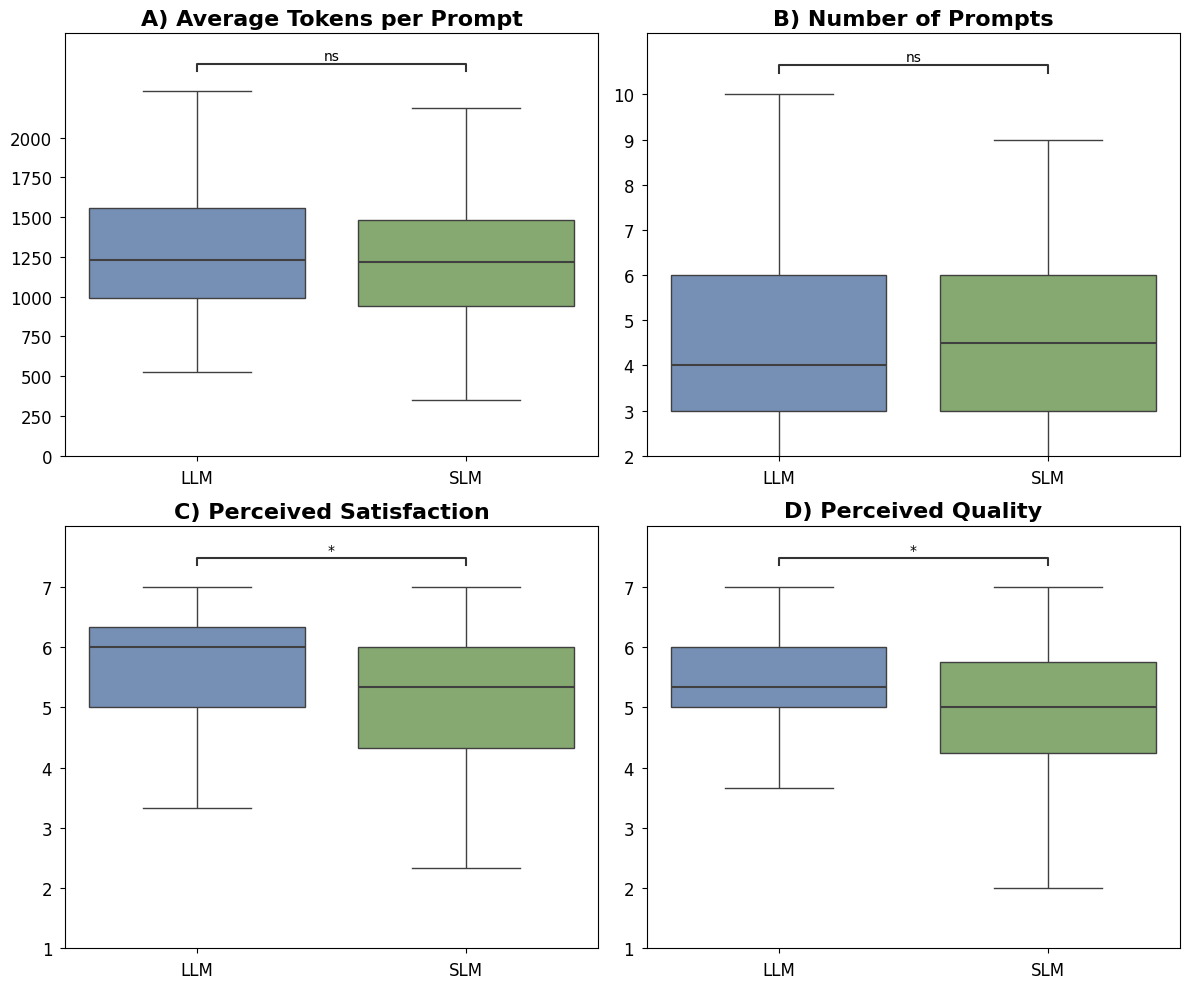

In [ ]:
from statannotations.Annotator import Annotator

fig, axes = plt.subplots(2, 2, figsize=(12, 10))  

title_map = {
    "avg_tokens_per_prompt": "A) Average Tokens per Prompt",
    "userMessageCount": "B) Number of Prompts",
    "SAT_MEAN": "C) Perceived Satisfaction",
    "QUAL_MEAN": "D) Perceived Quality",
}

variables = ["avg_tokens_per_prompt", "userMessageCount", "SAT_MEAN", "QUAL_MEAN"]
plot_palette = {"LLM": "#6C8EBF", "SLM": "#82B366"}
box_pairs = [("LLM", "SLM")]

# Flatten axes for easier indexing: [0,0], [0,1], [1,0], [1,1]
for i, var in enumerate(variables):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    sns.boxplot(
        ax=ax, data=data_treatment, x="choice", y=var,
        hue="choice", palette=plot_palette, legend=False,
        showfliers=False,
        boxprops={"edgecolor": "#404040", "linewidth": 1},
        whiskerprops={"color": "#404040", "linewidth": 1},
        capprops={"color": "#404040", "linewidth": 1},
        medianprops={"color": "#404040", "linewidth": 1.5},
    )
    
    # Y-limits (same as your original)
    if var == "userMessageCount":
        ax.set_ylim(2, 10)
        ax.set_yticks(np.arange(2, 11, 1))
    elif var == "avg_tokens_per_prompt":
        ax.set_ylim(100, 2100)
        ax.set_yticks(np.arange(0, 2100, 250))
    else:  # SAT_MEAN and QUAL_MEAN
        ax.set_ylim(1, 7)
        ax.set_yticks(np.arange(1, 8, 1))
    
    # Statistical annotation (same as yours)
    annotator = Annotator(ax=ax, pairs=box_pairs, data=data_treatment, x="choice", y=var)
    annotator.configure(text_format="star", loc="inside", comparisons_correction=None, verbose=2)
    annotator.set_pvalues_and_annotate([results[i]["p_bonf"]])
    
    ax.set_title(title_map[var], fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

# Format all axes tick labels
for ax in axes.flat:
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()

plt.savefig("img/ttests.pdf", bbox_inches="tight")
plt.savefig("img/ttests.svg", bbox_inches="tight")
plt.savefig("img/ttests.png", bbox_inches="tight",dpi = 600)

plt.show()
